In [18]:
from pathlib import Path

import pandas as pd
import numpy as np

DATA_DIR = Path("/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/data/drebin/")

df = pd.read_csv(DATA_DIR / "drebin215dataset5560malware9476benign.csv")

df.head()

/var/folders/zf/7vrgv7dn7qsbb8w1fnmwts7w0000gn/T/ipykernel_8207/3788122002.py:8: DtypeWarning: Columns (0: TelephonyManager.getSimCountryIso ) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_DIR / "drebin215dataset5560malware9476benign.csv")


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


In [12]:
#sanity checks
df.shape, df.columns[:10]
df['class'].value_counts()
df.isna().sum().head()

transact               0
onServiceConnected     0
bindService            0
attachInterface        0
ServiceConnection      0
dtype: int64

In [13]:
#Clean up mixed / non-numeric values in features

# 1 Replace '?' with 0
df = df.replace('?', 0)

# 2 Make sure all feature columns except 'class' are numeric
feature_cols = [c for c in df.columns if c != 'class']

for c in feature_cols:
    # change to numeric, turn any leftover non numeric into 0, then cast to int
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)

#quick sanity check
print(df.dtypes.head(10))
print()

transact                              int64
onServiceConnected                    int64
bindService                           int64
attachInterface                       int64
ServiceConnection                     int64
android.os.Binder                     int64
SEND_SMS                              int64
Ljava.lang.Class.getCanonicalName     int64
Ljava.lang.Class.getMethods           int64
Ljava.lang.Class.cast                 int64
dtype: object



In [14]:
from sklearn.model_selection import train_test_split

# Separate features and label
X = df.drop(columns=['class'])
y = df['class']

# 60% train, 20% val, 20% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42,
)

len(y_train), len(y_val), len(y_test), y_train.value_counts(normalize=True)

(9021,
 3007,
 3008,
 class
 B    0.630196
 S    0.369804
 Name: proportion, dtype: float64)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation Macro-F1: {val_f1_macro:.4f}")
print()
print("Validation classification report:")
print(classification_report(y_val, y_val_pred))

Validation accuracy: 0.9757
Validation Macro-F1: 0.9738

Validation classification report:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98      1895
           S       0.99      0.95      0.97      1112

    accuracy                           0.98      3007
   macro avg       0.98      0.97      0.97      3007
weighted avg       0.98      0.98      0.98      3007



In [16]:
y_test_pred = rf.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1_macro:.4f}")

Test accuracy: 0.9767
Test Macro-F1: 0.9748


In [25]:

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 20
top_features = X.columns[indices[:top_k]]
top_importances = importances[indices[:top_k]]

for name, imp in zip(top_features, top_importances):
    print(f"{name:40s} {imp:.4f}")

SEND_SMS                                 0.0751
android.os.Binder                        0.0482
READ_PHONE_STATE                         0.0477
transact                                 0.0457
android.telephony.SmsManager             0.0402
attachInterface                          0.0378
onServiceConnected                       0.0366
bindService                              0.0306
Ljava.lang.Class.getCanonicalName        0.0271
ServiceConnection                        0.0266
TelephonyManager.getLine1Number          0.0251
INTERNET                                 0.0251
TelephonyManager.getDeviceId             0.0235
RECEIVE_SMS                              0.0233
Ljava.net.URLDecoder                     0.0198
READ_SMS                                 0.0192
Ljava.lang.Class.cast                    0.0157
Ljava.lang.Class.getMethods              0.0156
android.intent.action.BOOT_COMPLETED     0.0135
Landroid.content.Context.unregisterReceiver  0.0132


In [26]:
from joblib import dump

MODEL_DIR = Path("/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "drebin_static_rf.pkl"
dump(rf, model_path)

model_path

PosixPath('/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models/drebin_static_rf.pkl')

In [28]:
# Encode labels for XGBoost: B to 0, S to 1
label_map = {'B': 0, 'S': 1}

y_train_enc = y_train.map(label_map)
y_val_enc   = y_val.map(label_map)
y_test_enc  = y_test.map(label_map)

y_train_enc.unique(), y_val_enc.unique(), y_test_enc.unique()

(array([1, 0]), array([1, 0]), array([0, 1]))

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",   # fast on CPU
    n_jobs=-1,
    random_state=42,
)

# use encoded labels here
xgb.fit(X_train, y_train_enc)

y_val_pred_xgb = xgb.predict(X_val)

val_acc_xgb = accuracy_score(y_val_enc, y_val_pred_xgb)
val_f1_macro_xgb = f1_score(y_val_enc, y_val_pred_xgb, average="macro")

print("XGBoost - validation")
print(f"  Accuracy:   {val_acc_xgb:.4f}")
print(f"  Macro-F1:   {val_f1_macro_xgb:.4f}")
print()
print(classification_report(
    y_val_enc,
    y_val_pred_xgb,
    target_names=["B", "S"]  # keeps the nice labels in the report
))

XGBoost - validation
  Accuracy:   0.9854
  Macro-F1:   0.9842

              precision    recall  f1-score   support

           B       0.98      0.99      0.99      1895
           S       0.99      0.97      0.98      1112

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.98      3007
weighted avg       0.99      0.99      0.99      3007



In [30]:
y_test_pred_xgb = xgb.predict(X_test)

test_acc_xgb = accuracy_score(y_test_enc, y_test_pred_xgb)
test_f1_macro_xgb = f1_score(y_test_enc, y_test_pred_xgb, average="macro")

print("XGBoost - test")
print(f"  Accuracy:   {test_acc_xgb:.4f}")
print(f"  Macro-F1:   {test_f1_macro_xgb:.4f}")

XGBoost - test
  Accuracy:   0.9847
  Macro-F1:   0.9835


In [31]:
from joblib import dump
from pathlib import Path

MODEL_DIR = Path("/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

dump(xgb, MODEL_DIR / "drebin_static_xgb.pkl")

['/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models/drebin_static_xgb.pkl']

In [37]:
import pandas as pd

# rf is the fitted RandomForestClassifier on X_train, y_train
# X_train still has all 215 feature columns

rf_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Take a quick look at the most important features
rf_importances.head(20)

SEND_SMS                                        0.075091
android.os.Binder                               0.048191
READ_PHONE_STATE                                0.047687
transact                                        0.045741
android.telephony.SmsManager                    0.040249
attachInterface                                 0.037806
onServiceConnected                              0.036567
bindService                                     0.030599
Ljava.lang.Class.getCanonicalName               0.027061
ServiceConnection                               0.026565
TelephonyManager.getLine1Number                 0.025117
INTERNET                                        0.025054
TelephonyManager.getDeviceId                    0.023541
RECEIVE_SMS                                     0.023257
Ljava.net.URLDecoder                            0.019793
READ_SMS                                        0.019154
Ljava.lang.Class.cast                           0.015680
Ljava.lang.Class.getMethods    

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

def evaluate_rf_with_feature_drop(k, base_rf_params=None):
    """
    Train a RandomForest after dropping the top-k important features.
    Returns val/test accuracy and Macro-F1.
    """
    if base_rf_params is None:
        base_rf_params = dict(
            n_estimators=200,
            max_depth=12,
            n_jobs=-1,
            random_state=42,
        )
    
    # Which features to drop?
    if k > 0:
        drop_feats = rf_importances.index[:k].tolist()
    else:
        drop_feats = []

    # Reduced feature sets (same rows, fewer columns)
    X_train_red = X_train.drop(columns=drop_feats)
    X_val_red   = X_val.drop(columns=drop_feats)
    X_test_red  = X_test.drop(columns=drop_feats)

    # Fresh RF (we don't reuse the old one)
    model = RandomForestClassifier(**base_rf_params)
    model.fit(X_train_red, y_train)

    # Validation performance
    y_val_pred = model.predict(X_val_red)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1  = f1_score(y_val, y_val_pred, average="macro")

    # Test performance
    y_test_pred = model.predict(X_test_red)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    return {
        "k_removed": k,
        "n_features_left": X_train_red.shape[1],
        "val_acc": val_acc,
        "val_macro_f1": val_f1,
        "test_acc": test_acc,
        "test_macro_f1": test_f1,
    }

In [41]:
k_values = [0, 10, 25, 50, 75, 100]

robust_results = []

for k in k_values:
    res = evaluate_rf_with_feature_drop(k)
    robust_results.append(res)
    print(
        f"k={k:3d} "
        f"| val Macro-F1={res['val_macro_f1']:.4f} "
        f"| test Macro-F1={res['test_macro_f1']:.4f}"
    )

robust_df = pd.DataFrame(robust_results)
robust_df

k=  0 | val Macro-F1=0.9738 | test Macro-F1=0.9748
k= 10 | val Macro-F1=0.9682 | test Macro-F1=0.9660
k= 25 | val Macro-F1=0.9538 | test Macro-F1=0.9549
k= 50 | val Macro-F1=0.9054 | test Macro-F1=0.9018
k= 75 | val Macro-F1=0.7854 | test Macro-F1=0.7751
k=100 | val Macro-F1=0.6271 | test Macro-F1=0.6341


,k_removed,n_features_left,val_acc,val_macro_f1,test_acc,test_macro_f1
0,0,215,0.975723,0.973752,0.976729,0.974811
1,10,205,0.970735,0.968200,0.968750,0.966024
2,25,190,0.957765,0.953770,0.958777,0.954899
3,50,165,0.914533,0.905407,0.911237,0.901833
4,75,140,0.804789,0.785393,0.797207,0.775053
5,100,115,0.727303,0.627057,0.732380,0.634090


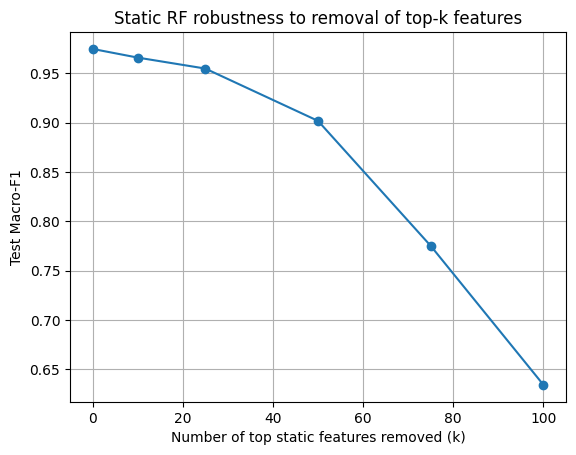

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(robust_df["k_removed"], robust_df["test_macro_f1"], marker="o")
plt.xlabel("Number of top static features removed (k)")
plt.ylabel("Test Macro-F1")
plt.title("Static RF robustness to removal of top-k features")
plt.grid(True)
plt.show()

In [44]:
import time

start = time.time()
rf.fit(X_train, y_train)
train_time_rf = time.time() - start

start = time.time()
_ = rf.predict(X_test)
predict_time_rf = time.time() - start

print(f"RF train time:    {train_time_rf:.3f} s")
print(f"RF predict time:  {predict_time_rf:.3f} s for {len(X_test)} samples")

RF train time:    0.257 s
RF predict time:  0.030 s for 3008 samples


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
import pandas as pd

# ----- RF grid search -----
rf_grid = [
    {"n_estimators": 200, "max_depth": 8},
    {"n_estimators": 200, "max_depth": 12},
    {"n_estimators": 500, "max_depth": 8},
    {"n_estimators": 500, "max_depth": 12},
]

rf_search_results = []
best_rf_cfg = None
best_rf_val_f1 = -1.0
best_rf_val_acc = None

for cfg in rf_grid:
    rf_model = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        n_jobs=-1,
        random_state=42,
    )
    rf_model.fit(X_train, y_train)
    y_val_pred = rf_model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1m = f1_score(y_val, y_val_pred, average="macro")

    rf_search_results.append({
        "model": "RF",
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "val_accuracy": acc,
        "val_macro_f1": f1m,
    })

    if f1m > best_rf_val_f1:
        best_rf_val_f1 = f1m
        best_rf_val_acc = acc
        best_rf_cfg = cfg

rf_search_df = pd.DataFrame(rf_search_results)
print("RF grid search results:")
display(rf_search_df)
print("\nBest RF config:", best_rf_cfg)
print(f"Best RF val Macro-F1: {best_rf_val_f1:.4f}, val Acc: {best_rf_val_acc:.4f}")

RF grid search results:


,model,n_estimators,max_depth,val_accuracy,val_macro_f1
0,RF,200,8,0.965081,0.962141
1,RF,200,12,0.975723,0.973752
2,RF,500,8,0.965747,0.962877
3,RF,500,12,0.975723,0.973752



Best RF config: {'n_estimators': 200, 'max_depth': 12}
Best RF val Macro-F1: 0.9738, val Acc: 0.9757


In [47]:
#  XGB grid search 
# we make sure label_map and encoded labels exist 
label_map = {'B': 0, 'S': 1}
y_train_enc = y_train.map(label_map)
y_val_enc   = y_val.map(label_map)
y_test_enc  = y_test.map(label_map)

xgb_grid = [
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.10},
    {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.10},
    {"n_estimators": 500, "max_depth": 6, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 8, "learning_rate": 0.05},
]

xgb_search_results = []
best_xgb_cfg = None
best_xgb_val_f1 = -1.0
best_xgb_val_acc = None

for cfg in xgb_grid:
    xgb_model = XGBClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    xgb_model.fit(X_train, y_train_enc)
    y_val_pred_enc = xgb_model.predict(X_val)

    acc = accuracy_score(y_val_enc, y_val_pred_enc)
    f1m = f1_score(y_val_enc, y_val_pred_enc, average="macro")

    xgb_search_results.append({
        "model": "XGB",
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "learning_rate": cfg["learning_rate"],
        "val_accuracy": acc,
        "val_macro_f1": f1m,
    })

    if f1m > best_xgb_val_f1:
        best_xgb_val_f1 = f1m
        best_xgb_val_acc = acc
        best_xgb_cfg = cfg

xgb_search_df = pd.DataFrame(xgb_search_results)
print("XGBoost grid search results:")
display(xgb_search_df)
print("\nBest XGB config:", best_xgb_cfg)
print(f"Best XGB val Macro-F1: {best_xgb_val_f1:.4f}, val Acc: {best_xgb_val_acc:.4f}")

XGBoost grid search results:


,model,n_estimators,max_depth,learning_rate,val_accuracy,val_macro_f1
0,XGB,200,6,0.05,0.982707,0.981358
1,XGB,200,8,0.05,0.984037,0.982798
2,XGB,200,6,0.10,0.986365,0.985315
3,XGB,200,8,0.10,0.985367,0.984244
4,XGB,500,6,0.05,0.986698,0.985676
5,XGB,500,8,0.05,0.987030,0.986048



Best XGB config: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05}
Best XGB val Macro-F1: 0.9860, val Acc: 0.9870


In [51]:
# combine train + val
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

y_train_full_enc = y_train_full.map(label_map)

# best RF on train+val 
best_rf = RandomForestClassifier(
    n_estimators=best_rf_cfg["n_estimators"],
    max_depth=best_rf_cfg["max_depth"],
    n_jobs=-1,
    random_state=42,
)
best_rf.fit(X_train_full, y_train_full)

y_test_pred_rf = best_rf.predict(X_test)
best_rf_test_acc = accuracy_score(y_test, y_test_pred_rf)
best_rf_test_f1  = f1_score(y_test, y_test_pred_rf, average="macro")

print("Best RF - test performance")
print(f"  Accuracy: {best_rf_test_acc:.4f}")
print(f"  Macro-F1: {best_rf_test_f1:.4f}")

Best RF - test performance
  Accuracy: 0.9767
  Macro-F1: 0.9748


In [50]:
# best XGB on train+val
best_xgb = XGBClassifier(
    n_estimators=best_xgb_cfg["n_estimators"],
    max_depth=best_xgb_cfg["max_depth"],
    learning_rate=best_xgb_cfg["learning_rate"],
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)
best_xgb.fit(X_train_full, y_train_full_enc)

y_test_pred_xgb_enc = best_xgb.predict(X_test)
best_xgb_test_acc = accuracy_score(y_test_enc, y_test_pred_xgb_enc)
best_xgb_test_f1  = f1_score(y_test_enc, y_test_pred_xgb_enc, average="macro")

print("Best XGB - test performance")
print(f"  Accuracy: {best_xgb_test_acc:.4f}")
print(f"  Macro-F1: {best_xgb_test_f1:.4f}")

Best XGB - test performance
  Accuracy: 0.9890
  Macro-F1: 0.9882


In [52]:
#  summary table (static RF vs XGB, val + test)
static_results = pd.DataFrame([
    {
        "model": "RF",
        "split": "val",
        "accuracy": best_rf_val_acc,
        "macro_f1": best_rf_val_f1,
    },
    {
        "model": "RF",
        "split": "test",
        "accuracy": best_rf_test_acc,
        "macro_f1": best_rf_test_f1,
    },
    {
        "model": "XGB",
        "split": "val",
        "accuracy": best_xgb_val_acc,
        "macro_f1": best_xgb_val_f1,
    },
    {
        "model": "XGB",
        "split": "test",
        "accuracy": best_xgb_test_acc,
        "macro_f1": best_xgb_test_f1,
    },
])

print("Static baseline summary (RF vs XGB):")
display(static_results)

Static baseline summary (RF vs XGB):


,model,split,accuracy,macro_f1
0,RF,val,0.975723,0.973752
1,RF,test,0.976729,0.974841
2,XGB,val,0.987030,0.986048
3,XGB,test,0.989029,0.988196


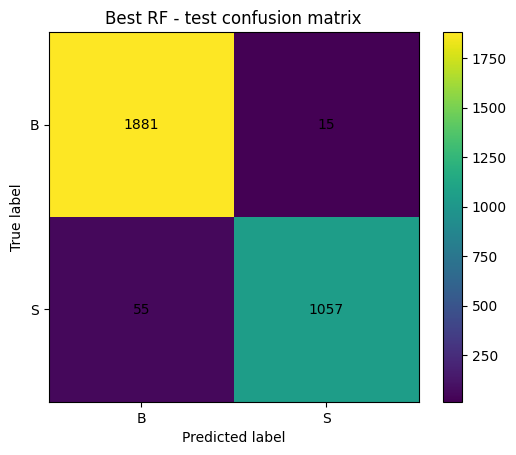

In [55]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=["B", "S"])

fig, ax = plt.subplots()
im = ax.imshow(cm_rf, interpolation="nearest")
ax.set_title("Best RF - test confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["B", "S"])
ax.set_yticklabels(["B", "S"])

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.show()

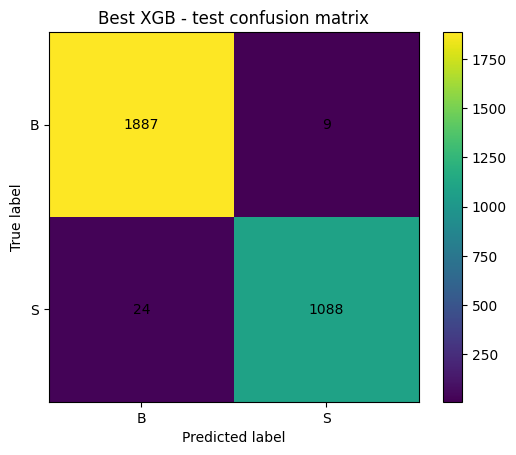

In [56]:
# XGB confusion matrix (here we decode predictions back to B/S)
inv_label_map = {0: "B", 1: "S"}
y_test_pred_xgb = pd.Series(y_test_pred_xgb_enc, index=y_test.index).map(inv_label_map)

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb, labels=["B", "S"])

fig, ax = plt.subplots()
im = ax.imshow(cm_xgb, interpolation="nearest")
ax.set_title("Best XGB - test confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["B", "S"])
ax.set_yticklabels(["B", "S"])

for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        ax.text(j, i, cm_xgb[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.show()

In [64]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

#Use the robustness results here
#robust_df already exists from the earlier robustness experiment
# columns are k_removed, n_features_left, val_acc, val_macro_f1, etc.)
df_res = robust_df.rename(columns={"val_acc": "val_accuracy"}).copy()

# baseline (k = 0) from the original RF we used for the robustness experiment
baseline_val_pred = rf.predict(X_val)
baseline_acc = accuracy_score(y_val, baseline_val_pred)
baseline_f1  = f1_score(y_val, baseline_val_pred, average="macro")

baseline_row = pd.DataFrame({
    "k_removed":   [0],
    "val_accuracy": [baseline_acc],
    "val_macro_f1": [baseline_f1],
})

# add baseline point and sort by k
df_res_with0 = pd.concat([baseline_row, df_res[["k_removed", "val_accuracy", "val_macro_f1"]]],
                         ignore_index=True)
df_res_with0 = df_res_with0.sort_values("k_removed")

x = df_res_with0["k_removed"].values.astype(float)
y = df_res_with0["val_macro_f1"].values.astype(float)

#manual trapezoidal integration AURC
dx    = np.diff(x)                 #differences in k
avg_y = (y[1:] + y[:-1]) / 2.0     #average F1 between adjacent points
aurc  = np.sum(avg_y * dx)         #sum of trapezoid areas

max_k_range = x.max() - x.min()
aurc_norm   = aurc / max_k_range if max_k_range > 0 else np.nan

print("Static RF robustness to top-k removal:")
print("  AURC (unnormalised):", round(float(aurc), 4))
print("  AURC (normalised 0-1):", round(float(aurc_norm), 4))

Static RF robustness to top-k removal:
  AURC (unnormalised): 86.1548
  AURC (normalised 0-1): 0.8615


In [65]:
import time
import os
from pathlib import Path
from joblib import dump

# makes sure MODEL_DIR exists
MODEL_DIR = Path("/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def time_model(model, X_tr, y_tr, X_te):
    """Return (train_time_seconds, predict_time_seconds)."""
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    start = time.time()
    _ = model.predict(X_te)
    predict_time = time.time() - start

    return train_time, predict_time

# time best RF 
rf_for_timing = RandomForestClassifier(
    n_estimators=best_rf_cfg["n_estimators"],
    max_depth=best_rf_cfg["max_depth"],
    n_jobs=-1,
    random_state=42,
)
rf_train_t, rf_pred_t = time_model(rf_for_timing, X_train_full, y_train_full, X_test)

# time best XGB
xgb_for_timing = XGBClassifier(
    n_estimators=best_xgb_cfg["n_estimators"],
    max_depth=best_xgb_cfg["max_depth"],
    learning_rate=best_xgb_cfg["learning_rate"],
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)
xgb_train_t, xgb_pred_t = time_model(xgb_for_timing, X_train_full, y_train_full_enc, X_test)

#saves the already-trained best models (this is from earlier not the timing ones)
best_rf_path = MODEL_DIR / "drebin_static_rf_best.pkl"
best_xgb_path = MODEL_DIR / "drebin_static_xgb_best.pkl"
dump(best_rf, best_rf_path)
dump(best_xgb, best_xgb_path)

rf_size_mb = os.path.getsize(best_rf_path) / (1024 ** 2)
xgb_size_mb = os.path.getsize(best_xgb_path) / (1024 ** 2)

cost_table = pd.DataFrame([
    {
        "model": "RF",
        "train_time_s": rf_train_t,
        "predict_time_s": rf_pred_t,
        "predict_time_per_sample_ms": 1000.0 * rf_pred_t / len(X_test),
        "model_size_MB": rf_size_mb,
    },
    {
        "model": "XGB",
        "train_time_s": xgb_train_t,
        "predict_time_s": xgb_pred_t,
        "predict_time_per_sample_ms": 1000.0 * xgb_pred_t / len(X_test),
        "model_size_MB": xgb_size_mb,
    },
])

print("Static model cost metrics (for E4-accuracy vs cost):")
display(cost_table)

Static model cost metrics (for E4-accuracy vs cost):


,model,train_time_s,predict_time_s,predict_time_per_sample_ms,model_size_MB
0,RF,0.268901,0.026097,0.008676,8.497308
1,XGB,1.007483,0.009048,0.003008,1.392837
